In [ ]:
import os 
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")

In [ ]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from scipy.stats import t
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import weibull_min
import plotly.graph_objects as go

from models.phVAE import *
from steps.model_training import *

# Synthetic datasets

## Data creation using t-copula

In [2]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import norm, t as student_t
from scipy.stats import weibull_min, pareto, lognorm, burr12

def make_toeplitz_corr(k, rho=0.6):
    idx = np.arange(k)
    C = rho ** np.abs(idx[:, None] - idx[None, :])
    return C

def sample_copula_uniforms(N, Corr, copula="gaussian", df=4, seed=0):
    
     
    rng = np.random.default_rng(seed)
    k = Corr.shape[0]
    L = np.linalg.cholesky(Corr)

    Z = rng.standard_normal(size=(N, k)) @ L.T  
    if copula == "gaussian":
        U = norm.cdf(Z)
    elif copula == "t":
        g = rng.chisquare(df, size=(N, 1))
        T = Z / np.sqrt(g / df)
        U = student_t.cdf(T, df=df)
    else:
        raise ValueError("copula must be 'gaussian' or 't'")

    U = np.clip(U, 1e-12, 1 - 1e-12)
    return U

def inv_cdf_marginal(u, dist_name, params):
    
    if dist_name == "weibull": 
        k_shape = params.get("k", 0.7)    
        lam = params.get("lam", 1.0)
        return weibull_min.ppf(u, c=k_shape, scale=lam)

    if dist_name == "pareto":
        a = params.get("a", 2.0)           
        xm = params.get("xm", 1.0)        
        return pareto.ppf(u, b=a, scale=xm)

    if dist_name == "lognormal":
        sigma = params.get("sigma", 1.0)
        scale = params.get("scale", 1.0)   
        return lognorm.ppf(u, s=sigma, scale=scale)

    if dist_name == "burr":
        c = params.get("c", 1.5)
        d = params.get("d", 2.0)
        scale = params.get("scale", 1.0)
        return burr12.ppf(u, c=c, d=d, scale=scale)

    raise ValueError(f"Unknown dist_name: {dist_name}")

def make_correlated_heavy_tail_data(
    N=50_000,
    k=2,
    rho=0.7,
    copula="t",         
    df=4,                
    dist_names=None,     
    dist_params=None,    
    standardize=None,   
    seed=0,
    device="cpu",
):
   
    
    Corr = make_toeplitz_corr(k, rho=rho)
    ## testing another corr
    import numpy as np

    def ar1_corr(k, rho):
        idx = np.arange(k)
        return rho ** np.abs(idx[:, None] - idx[None, :])

    def block_diag_corr(blocks):
        """blocks: list of correlation matrices; returns block diagonal correlation."""
        k = sum(b.shape[0] for b in blocks)
        C = np.zeros((k, k))
        i = 0
        for b in blocks:
            s = b.shape[0]
            C[i:i+s, i:i+s] = b
            i += s
        return C

    # Example: dims 0-1 independent from dims 2..k-1
    
    Corr = block_diag_corr([
        np.eye(2),                 # dims 0,1 are independent (corr=0)
        ar1_corr(k-2, rho=0.7),     # remaining dims correlated
    ])

    ###########
    U = sample_copula_uniforms(N, Corr, copula=copula, df=df, seed=seed)  # [N,k]

    if dist_names is None:
        # a strong default mix for demos
        dist_names = ["pareto", "weibull", "lognormal", "burr", "pareto", "pareto", "weibull", "lognormal", "burr", "pareto"][:k]

    if dist_params is None:
        dist_params = []
        for name in dist_names:
            if name == "pareto":
                dist_params.append({"a": 2.2, "xm": 1.0})
            elif name == "weibull":
                dist_params.append({"k": 0.7, "lam": 1.0})
            elif name == "lognormal":
                dist_params.append({"sigma": 1.0, "scale": 1.0})
            elif name == "burr":
                dist_params.append({"c": 1.4, "d": 2.2, "scale": 1.0})
            else:
                dist_params.append({})

    X = np.zeros((N, k), dtype=np.float64)
    for j in range(k):
        X[:, j] = inv_cdf_marginal(U[:, j], dist_names[j], dist_params[j])


    if standardize == "log1p_zscore":
        X = np.log1p(X)
        X = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-12)

    x = torch.tensor(X, dtype=torch.float32, device=device)

    meta = {
        "Corr": Corr,
        "copula": copula,
        "df": df,
        "dist_names": dist_names,
        "dist_params": dist_params,
        "rho": rho,
        "standardize": standardize,
        "seed": seed,
    }
    return x, meta

def make_loader(x, batch_size=256, shuffle=True):
    ds = TensorDataset(x)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


In [3]:
import numpy as np
import pandas as pd

def true_cdf(x, dist_name, params):
    if dist_name == "weibull":
        return weibull_min.cdf(x, c=params["k"], scale=params["lam"])
    if dist_name == "pareto":
        return pareto.cdf(x, b=params["a"], scale=params["xm"])
    if dist_name == "lognormal":
        return lognorm.cdf(x, s=params["sigma"], scale=params["scale"])
    if dist_name == "burr":
        return burr12.cdf(x, c=params["c"], d=params["d"], scale=params["scale"])
    raise ValueError(dist_name)

def true_ppf(q, dist_name, params):
    if dist_name == "weibull":
        return weibull_min.ppf(q, c=params["k"], scale=params["lam"])
    if dist_name == "pareto":
        return pareto.ppf(q, b=params["a"], scale=params["xm"])
    if dist_name == "lognormal":
        return lognorm.ppf(q, s=params["sigma"], scale=params["scale"])
    if dist_name == "burr":
        return burr12.ppf(q, c=params["c"], d=params["d"], scale=params["scale"])
    raise ValueError(dist_name)


def ks_tail_conditional(model_samples, dist_name, params, q=0.95, min_tail=200):
    Qq_true = true_ppf(q, dist_name, params)

    ms = np.asarray(model_samples)
    tail = np.sort(ms[ms > Qq_true])
    if tail.size < min_tail:
        return np.nan

    F_model_cond = np.arange(1, tail.size + 1) / tail.size

    F_true = true_cdf(tail, dist_name, params)
    F_true_cond = (F_true - q) / (1 - q)
    F_true_cond = np.clip(F_true_cond, 0, 1)

    return np.max(np.abs(F_model_cond - F_true_cond))

def q99_errors(model_samples, dist_name, params):
    Q99_true = true_ppf(0.99, dist_name, params)
    Q99_model = np.quantile(np.asarray(model_samples), 0.99)
    abs_err = abs(Q99_model - Q99_true)
    rel_err = abs_err / (Q99_true + 1e-12)
    return abs_err, rel_err


## 5D data

In [4]:
# 5D
dim =5
x5, meta5 = make_correlated_heavy_tail_data(
    N=80_000,
    k=dim,
    rho=0.6,
    copula="t",
    df=4,
    seed=1,
    device='cpu'
)
loader5 = make_loader(x5, batch_size=512)

print("x5:", x5.shape, "min:", x5.min().item(), "mean:", x5.mean().item())

x5: torch.Size([80000, 5]) min: 2.0216226914726576e-07 mean: 1.4513200521469116


In [15]:
model = phVAE.MultiDimPHVAE(input_dim=dim, latent_dim=10, n_phases=15)
train_phvae(
    model,
    loader5,
    epochs=13,
    learning_rate=1e-2,
    beta=1,           
    grad_clip=1.0,
    save_every=10,
    reduce_lr=False,
    model_type='PH-VAE-MULTI'
)

Epoch 1/13: 100%|██████████| 157/157 [00:13<00:00, 11.98it/s]


Epoch 001 | Loss: 6.7803 | Recon: -5.2208 | KL: 1.5596 | Time/epoch: 13.11s


Epoch 2/13: 100%|██████████| 157/157 [00:14<00:00, 11.06it/s]


Epoch 002 | Loss: 5.0390 | Recon: -5.0385 | KL: 0.0005 | Time/epoch: 14.20s


Epoch 3/13: 100%|██████████| 157/157 [00:14<00:00, 10.82it/s]


...

Epoch 005 | Loss: 5.0287 | Recon: -5.0287 | KL: 0.0000 | Time/epoch: 14.82s


Epoch 6/13: 100%|██████████| 157/157 [00:14<00:00, 10.84it/s]


Epoch 006 | Loss: 5.0279 | Recon: -5.0278 | KL: 0.0001 | Time/epoch: 14.48s


Epoch 7/13:  27%|██▋       | 43/157 [00:04<00:10, 10.56it/s]


KeyboardInterrupt: 

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# from scipy.stats import weibull_min, pareto, lognorm, burr12


# def true_pdf(x, dist_name, params):
#     if dist_name == "weibull":
#         return weibull_min.pdf(
#             x,
#             c=params["k"],
#             scale=params["lam"]
#         )

#     if dist_name == "pareto":
#         return pareto.pdf(
#             x,
#             b=params["a"],
#             scale=params["xm"]
#         )

#     if dist_name == "lognormal":
#         return lognorm.pdf(
#             x,
#             s=params["sigma"],
#             scale=params["scale"]
#         )

#     if dist_name == "burr":
#         return burr12.pdf(
#             x,
#             c=params["c"],
#             d=params["d"],
#             scale=params["scale"]
#         )

#     raise ValueError(f"Unknown distribution: {dist_name}")



# dims = [0,1,2,3,4]              
# N = 1_000_000

# model.eval()
# device = next(model.parameters()).device

# with torch.no_grad():
#     z = torch.randn(N, model.latent_dim, device=device)
#     alphas, As, ts = model.decode_params(z)

# plt.figure(figsize=(5 * len(dims), 4))

# for i, j in enumerate(dims):

#     # PH-VAE samples (dimension j)
#     ph_samples_j = ph_sample_batch(
#         alphas[j], As[j], ts[j]
#     ).cpu().numpy()

#     # True data samples
#     data_j = x5[:, j].cpu().numpy()

#     # True marginal info
#     dist_name = meta5["dist_names"][j]
#     dist_param = meta5["dist_params"][j]

#     # Grid
#     x_max = max(ph_samples_j.max(), data_j.max())
#     x_grid = np.linspace(0, x_max, 500)

#     pdf_true = true_pdf(x_grid, dist_name, dist_param)

#     # Plot
#     plt.subplot(1, len(dims), i + 1)
#     sns.histplot(
#         ph_samples_j,
#         bins=80,
#         stat="density",
#         alpha=0.6,
#         label="PH-VAE samples"
#     )
#     plt.plot(
#         x_grid,
#         pdf_true,
#         "r-",
#         lw=2,
#         label=f"True {dist_name}"
#     )

#     plt.yscale("log")
#     plt.xlabel("x")
#     plt.title(f"Dim {j} ({dist_name})")
#     if i == 0:
#         plt.ylabel("Density")
#     plt.legend()

# plt.suptitle(
#     "Multidimensional PH-VAE: marginal fit per dimension",
#     y=1.05
# )
# plt.tight_layout()
# plt.show()


In [ ]:

results = []

model.eval()
device = next(model.parameters()).device

N = 200_000
with torch.no_grad():
    z = torch.randn(N, model.latent_dim, device=device)
    alphas, As, ts = model.decode_params(z)

for j in range(x5.shape[1]):

    # PH-VAE samples
    ph_samples_j = ph_sample_batch(
        alphas[j], As[j], ts[j]
    ).cpu().numpy()

    # True marginal info
    dist_name = meta5["dist_names"][j]
    params = meta5["dist_params"][j]

    # Metrics
    ks_tail = ks_tail_conditional(
        ph_samples_j,
        dist_name,
        params,
        q=0.95
    )

    Q99_true = true_ppf(0.99, dist_name, params)
    Q99_model = np.quantile(ph_samples_j, 0.99)

    abs_err = abs(Q99_model - Q99_true)
    rel_err = abs_err / Q99_true

    results.append({
        "Dim": j,
        "Distribution": dist_name,
        "KS_tail@0.95": ks_tail,
        "Q99_abs_err": abs_err,
        "Q99_rel_err": rel_err,
    })

df_results = pd.DataFrame(results)
df_results


,Dim,Distribution,KS_tail@0.95,Q99_abs_err,Q99_rel_err
0,0,pareto,0.020440,0.050357,0.006208
1,1,weibull,0.059261,0.718794,0.081117
2,2,lognormal,0.078659,2.132734,0.208265
3,3,burr,0.084038,1.025809,0.252657
4,4,pareto,0.076132,2.068477,0.255012


In [74]:
import numpy as np
import torch
from scipy.stats import kendalltau
import itertools


model.eval()
device = next(model.parameters()).device

N_gen = 200_000
with torch.no_grad():
    z = torch.randn(N_gen, model.latent_dim, device=device)
    alphas, As, ts = model.decode_params(z)
    x_gen = ph_sample_multidim(alphas, As, ts).cpu().numpy()

x_real = x5.cpu().numpy()[:N_gen]  # match size
k = x_real.shape[1]


Xr = np.log1p(x_real)
Xg = np.log1p(x_gen)

corr_real = np.corrcoef(Xr, rowvar=False)
corr_gen  = np.corrcoef(Xg, rowvar=False)

corr_error = np.linalg.norm(corr_real - corr_gen, ord="fro")


tau_errs = []
for i, j in itertools.combinations(range(k), 2):
    tau_r, _ = kendalltau(x_real[:, i], x_real[:, j])
    tau_g, _ = kendalltau(x_gen[:, i],  x_gen[:, j])
    if np.isfinite(tau_r) and np.isfinite(tau_g):
        tau_errs.append(abs(tau_r - tau_g))

kendall_tau_error = np.mean(tau_errs)


qs = [0.95, 0.97, 0.99]
tail_results = {}

for q in qs:
    abs_pair_errors = []
    probs_real = []
    probs_gen  = []

    for i, j in itertools.combinations(range(k), 2):
        # Quantiles from REAL data only
        qi = np.quantile(x_real[:, i], q)
        qj = np.quantile(x_real[:, j], q)

        p_real = np.mean((x_real[:, i] > qi) & (x_real[:, j] > qj))
        p_gen  = np.mean((x_gen[:,  i] > qi) & (x_gen[:,  j] > qj))

        probs_real.append(p_real)
        probs_gen.append(p_gen)
        abs_pair_errors.append(abs(p_gen - p_real))

    tail_results[q] = {
        "real": np.mean(probs_real),
        "gen":  np.mean(probs_gen),
        "abs_error": np.mean(abs_pair_errors),
    }


print("=== Dependence evaluation (synthetic) ===")
print(f"Correlation error (log1p, Frobenius): {corr_error:.4f}")
print(f"Mean Kendall τ error:                {kendall_tau_error:.4f}")
print("\nTail co-exceedance (avg over pairs):")
for q, v in tail_results.items():
    print(
        f"  q={q:.2f} | "
        f"real={v['real']:.4e} | "
        f"gen={v['gen']:.4e} | "
        f"abs_err={v['abs_error']:.2e}"
    )


=== Dependence evaluation (synthetic) ===
Correlation error (log1p, Frobenius): 1.4869
Mean Kendall τ error:                0.1328

Tail co-exceedance (avg over pairs):
  q=0.95 | real=1.0630e-02 | gen=2.6160e-03 | abs_err=8.01e-03
  q=0.97 | real=5.8712e-03 | gen=9.3850e-04 | abs_err=4.93e-03
  q=0.99 | real=1.8000e-03 | gen=1.0350e-04 | abs_err=1.70e-03


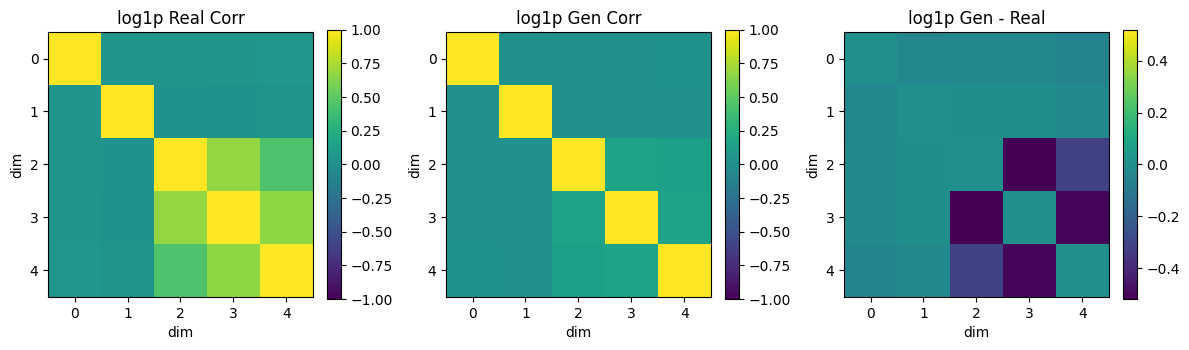

pair (0,1): target=+0.700, real=+0.040, gen=+0.001
pair (0,2): target=+0.490, real=+0.034, gen=+0.009
pair (1,2): target=+0.700, real=+0.017, gen=+0.014


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# def corr_on_scale(X, scale="log1p"):
#     """
#     X: [N, k]
#     scale: "raw" or "log1p"
#     """
#     if scale == "log1p":
#         Xs = np.log1p(X)
#     elif scale == "raw":
#         Xs = X
#     else:
#         raise ValueError("scale must be 'raw' or 'log1p'")
#     return np.corrcoef(Xs, rowvar=False)

# def plot_corr_triplet(C_real, C_gen, title_prefix="", vmax=1.0):
#     """
#     Plots: real corr, gen corr, diff.
#     """
#     D = C_gen - C_real

#     fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
#     im0 = axes[0].imshow(C_real, vmin=-vmax, vmax=vmax)
#     axes[0].set_title(f"{title_prefix} Real Corr")
#     axes[0].set_xlabel("dim"); axes[0].set_ylabel("dim")

#     im1 = axes[1].imshow(C_gen, vmin=-vmax, vmax=vmax)
#     axes[1].set_title(f"{title_prefix} Gen Corr")
#     axes[1].set_xlabel("dim"); axes[1].set_ylabel("dim")

#     # difference usually small; use symmetric limits based on max abs
#     lim = max(1e-6, np.max(np.abs(D)))
#     im2 = axes[2].imshow(D, vmin=-lim, vmax=lim)
#     axes[2].set_title(f"{title_prefix} Gen - Real")
#     axes[2].set_xlabel("dim"); axes[2].set_ylabel("dim")

#     fig.colorbar(im0, ax=axes[0], fraction=0.046)
#     fig.colorbar(im1, ax=axes[1], fraction=0.046)
#     fig.colorbar(im2, ax=axes[2], fraction=0.046)
#     fig.tight_layout()
#     return fig

# def report_pairs(C_target, C_real, C_gen, pairs):
#     """
#     pairs: list of (i,j)
#     """
#     rows = []
#     for (i, j) in pairs:
#         rows.append((i, j, C_target[i,j], C_real[i,j], C_gen[i,j]))
#     return rows

# # ---------------------------
# # Example usage inside your experiment
# # ---------------------------
# # x_real: [N,k] numpy, x_gen: [N,k] numpy, C_target: [k,k] numpy

# C_real = corr_on_scale(x_real, scale="log1p")
# C_gen  = corr_on_scale(x_gen,  scale="log1p")

# plot_corr_triplet(C_real, C_gen, title_prefix="log1p", vmax=1.0)
# plt.show()

# # highlight known-zero pairs
# zero_pairs = [(0,1), (0,2), (1,2)]  # example
# Corr = make_toeplitz_corr(k, rho=0.7)
# rows = report_pairs(Corr, C_real, C_gen, zero_pairs)
# for (i,j,ct,cr,cg) in rows:
#     print(f"pair ({i},{j}): target={ct:+.3f}, real={cr:+.3f}, gen={cg:+.3f}")


In [ ]:
# independent phs

import torch
import numpy as np
import itertools

device = "cuda" if torch.cuda.is_available() else "cpu"

k = x5.shape[1]          # number of dimensions
N_gen = 200_000        # number of generated samples


indep_models = []

for j in range(k):
    print(f"\nTraining independent PH-VAE for dim {j}")

    xj = x5[:, j:j+1]  # shape [N,1]
    loader_j = make_loader(xj, batch_size=8192)

    model_j = phVAE.FeedForwardPHVAE(
        input_dim=1,
        latent_dim=10,
        n_phases=15
    ).to(device)

    train_phvae(
        model_j,
        loader_j,
        epochs=13,
        learning_rate=1e-2,
        beta=1.0,
        grad_clip=1.0,
        reduce_lr=False,
        model_type="PH-VAE"
    )

    indep_models.append(model_j)

print("\nAll independent 1D models trained.")




Training independent PH-VAE for dim 0


Epoch 1/13: 100%|██████████| 10/10 [00:35<00:00,  3.51s/it]


Epoch 001 | Loss: 136.9893 | Recon: -1.1623 | KL: 135.8270 | Time/epoch: 35.07s


Epoch 2/13: 100%|██████████| 10/10 [00:40<00:00,  4.08s/it]


Epoch 002 | Loss: 374457.5046 | Recon: -1.0257 | KL: 374456.4650 | Time/epoch: 40.82s


...

Epoch 011 | Loss: 0.9333 | Recon: -0.9333 | KL: 0.0000 | Time/epoch: 36.82s


Epoch 12/13: 100%|██████████| 10/10 [00:34<00:00,  3.48s/it]


Epoch 012 | Loss: 0.9331 | Recon: -0.9331 | KL: 0.0000 | Time/epoch: 34.84s


Epoch 13/13: 100%|██████████| 10/10 [00:36<00:00,  3.68s/it]

Epoch 013 | Loss: 0.9340 | Recon: -0.9340 | KL: 0.0000 | Time/epoch: 36.79s

Total training time: 477.94s (36.76s/epoch avg)
Mean time/epoch: 36.76 ± 1.09 s

All independent 1D models trained.


In [15]:

samples_indep = []

with torch.no_grad():
    for j, model_j in enumerate(indep_models):
        model_j.eval()
        z = torch.randn(N_gen, model_j.latent_dim, device=device)
        alpha, A, t = model_j.decode_params(z)
        xj = ph_sample_batch(alpha, A, t).cpu().numpy()
        samples_indep.append(xj[:, None])

x_gen_indep = np.concatenate(samples_indep, axis=1)  # [N_gen, k]
x_real = x5.cpu().numpy()[:N_gen]



#  correlation error (log1p)
Xr = np.log1p(x_real)
Xi = np.log1p(x_gen_indep)

corr_real = np.corrcoef(Xr, rowvar=False)
corr_indep = np.corrcoef(Xi, rowvar=False)

corr_error_indep = np.linalg.norm(corr_real - corr_indep, ord="fro")

#  Kendall tau error
from scipy.stats import kendalltau

tau_errs = []
for i, j in itertools.combinations(range(k), 2):
    tau_r, _ = kendalltau(x_real[:, i], x_real[:, j])
    tau_i, _ = kendalltau(x_gen_indep[:, i], x_gen_indep[:, j])
    if np.isfinite(tau_r) and np.isfinite(tau_i):
        tau_errs.append(abs(tau_r - tau_i))

kendall_tau_error_indep = np.mean(tau_errs)

#  tail co-exceedance
qs = [0.95, 0.97, 0.99]
tail_results = {}

for q in qs:
    abs_pair_errors = []
    probs_real = []
    probs_gen  = []

    for i, j in itertools.combinations(range(k), 2):
        qi_r = np.quantile(x_real[:, i], q)
        qj_r = np.quantile(x_real[:, j], q)
        qi_g = np.quantile(x_gen_indep[:, i],  q)
        qj_g = np.quantile(x_gen_indep[:, j],  q)

        p_real = np.mean((x_real[:, i] > qi_r) & (x_real[:, j] > qj_r))
        p_gen  = np.mean((x_gen_indep[:, i]  > qi_g) & (x_gen_indep[:, j]  > qj_g))

        probs_real.append(p_real)
        probs_gen.append(p_gen)

        abs_pair_errors.append(abs(p_gen - p_real))

    tail_results[q] = {
        "real": np.mean(probs_real),
        "gen":  np.mean(probs_gen),
        "abs_error": np.mean(abs_pair_errors),
    }

print("\n=== Independent PH baseline (per-dim) ===")
print(f"Correlation error (log1p, Frobenius): {corr_error_indep:.4f}")
print(f"Mean Kendall τ error:                {kendall_tau_error_indep:.4f}")
print("\nTail co-exceedance (avg over pairs):")
for q, v in tail_results.items():
    print(
        f"  q={q:.2f} | "
        f"real={v['real']:.4e} | "
        f"gen={v['gen']:.4e} | "
        f"abs_err={v['abs_error']:.2e}"
    )



=== Independent PH baseline (per-dim) ===
Correlation error (log1p, Frobenius): 1.4865
Mean Kendall τ error:                0.1319

Tail co-exceedance (avg over pairs):
  q=0.95 | real=1.0630e-02 | gen=2.5650e-03 | abs_err=8.06e-03
  q=0.97 | real=5.8712e-03 | gen=9.3900e-04 | abs_err=4.93e-03
  q=0.99 | real=1.8000e-03 | gen=1.0650e-04 | abs_err=1.69e-03


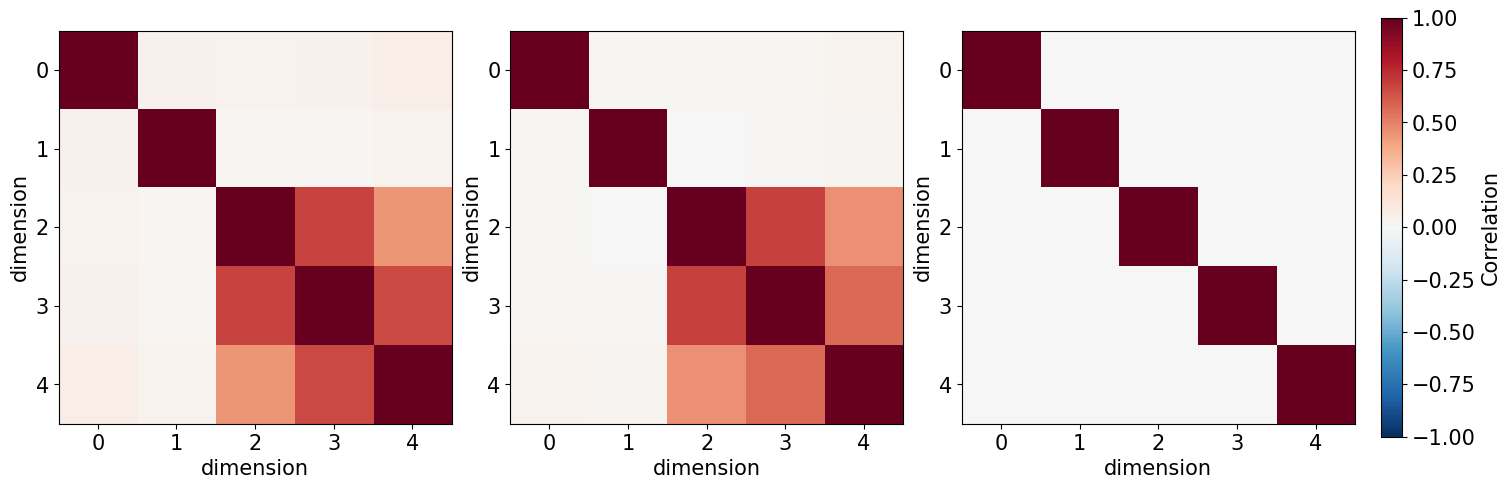

In [ ]:
# vmax=1.0
# C_real = corr_on_scale(x_real, scale="log1p")
# C_gen  = corr_on_scale(x_gen,  scale="log1p")
# C_gen_indep = corr_on_scale(x_gen_indep,scale="log1p")

# import matplotlib.pyplot as plt
# import numpy as np

# vmin, vmax = -1.0, 1.0
# cmap = "RdBu_r"

# fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

# titles = [
#     "Real correlation (log1p)",
#     "PH-VAE generated correlation (log1p)",
#     "Independent baseline correlation (log1p)"
# ]

# mats = [C_real, C_gen, C_gen_indep]

# for ax, C, title in zip(axes, mats, titles):
#     im = ax.imshow(
#         C,
#         vmin=vmin,
#         vmax=vmax,
#         cmap=cmap,
#         aspect="equal"
#     )
#     #ax.set_title(title, fontsize=13)
#     ax.set_xlabel("dimension", fontsize=15)
#     ax.set_ylabel("dimension", fontsize=15)

#     ax.set_xticks(np.arange(C.shape[0]))
#     ax.set_yticks(np.arange(C.shape[0]))
#     ax.tick_params(axis="both", labelsize=15)

# # Single shared colorbar on the right
# cbar = fig.colorbar(
#     im,
#     ax=axes,
#     fraction=0.025,
#     pad=0.02,
# )
# cbar.ax.tick_params(labelsize=15)

# cbar.set_label("Correlation", fontsize=15)




## 2D data

In [ ]:
# # 2D
# dim =2
# x2, meta2 = make_correlated_heavy_tail_data(
#     N=80_000,
#     k=dim,
#     rho=0.6,
#     copula="t",
#     df=4,
#     seed=1,
#     device='cpu'
# )
# loader2 = make_loader(x2, batch_size=512)
    

# print("x2:", x2.shape, "min:", x2.min().item(), "mean:", x2.mean().item())

x2: torch.Size([80000, 2]) min: 5.702578960153915e-07 mean: 1.5473638772964478


In [ ]:
# model2d = phVAE.MultiDimPHVAE(input_dim=dim, latent_dim=10, n_phases=15)
# train_phvae(
#     model2d,
#     loader2,
#     epochs=13,
#     learning_rate=1e-2,
#     beta=1,           
#     grad_clip=1.0,
#     save_every=10,
#     reduce_lr=False,
#     model_type='PH-VAE-MULTI'
# )

/home/hakimmics/myenv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2757: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


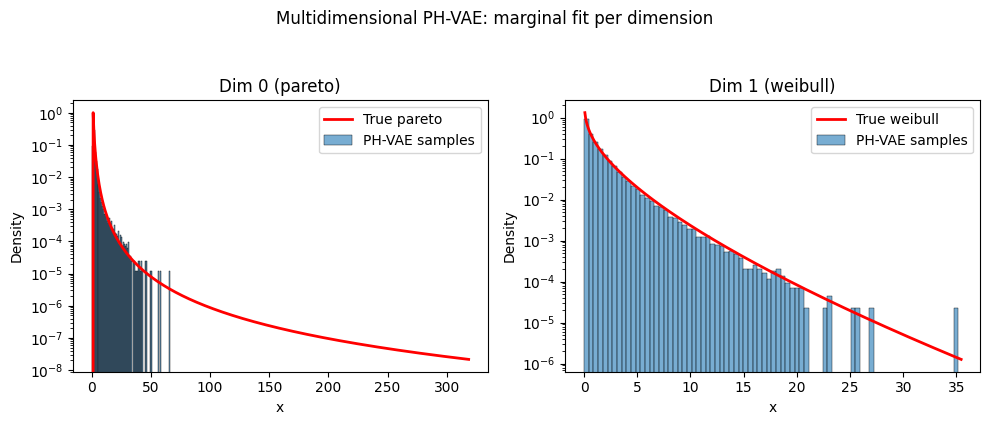

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# from scipy.stats import weibull_min, pareto, lognorm, burr12


# # true PDF dispatcher

# def true_pdf(x, dist_name, params):
#     if dist_name == "weibull":
#         return weibull_min.pdf(
#             x,
#             c=params["k"],
#             scale=params["lam"]
#         )

#     if dist_name == "pareto":
#         return pareto.pdf(
#             x,
#             b=params["a"],
#             scale=params["xm"]
#         )

#     if dist_name == "lognormal":
#         return lognorm.pdf(
#             x,
#             s=params["sigma"],
#             scale=params["scale"]
#         )

#     if dist_name == "burr":
#         return burr12.pdf(
#             x,
#             c=params["c"],
#             d=params["d"],
#             scale=params["scale"]
#         )

#     raise ValueError(f"Unknown distribution: {dist_name}")


# # Evaluation parameters
# dims = [0,1]          
# N = 100_000

# model2d.eval()
# device = next(model2d.parameters()).device

# # Sample from PH-VAE
# with torch.no_grad():
#     z = torch.randn(N, model2d.latent_dim, device=device)
#     alphas, As, ts = model2d.decode_params(z)

# plt.figure(figsize=(5 * len(dims), 4))

# # Loop over dimensions
# for i, j in enumerate(dims):

#     # PH-VAE samples (dimension j)
#     ph_samples_j = ph_sample_batch(
#         alphas[j], As[j], ts[j]
#     ).cpu().numpy()

#     # True data samples
#     data_j = x2[:, j].cpu().numpy()

#     # True marginal info
#     dist_name = meta2["dist_names"][j]
#     dist_param = meta2["dist_params"][j]

#     # Grid
#     x_max = max(ph_samples_j.max(), data_j.max())
#     x_grid = np.linspace(0, x_max, 500)

#     pdf_true = true_pdf(x_grid, dist_name, dist_param)

#     # Plot
#     plt.subplot(1, len(dims), i + 1)
#     sns.histplot(
#         ph_samples_j,
#         bins=80,
#         stat="density",
#         alpha=0.6,
#         label="PH-VAE samples"
#     )
#     plt.plot(
#         x_grid,
#         pdf_true,
#         "r-",
#         lw=2,
#         label=f"True {dist_name}"
#     )

#     plt.yscale("log")
#     plt.xlabel("x")
#     plt.title(f"Dim {j} ({dist_name})")
#     if i == 0:
#         plt.ylabel("Density")
#     plt.legend()

# plt.suptitle(
#     "Multidimensional PH-VAE: marginal fit per dimension",
#     y=1.05
# )
# plt.tight_layout()
# plt.show()


In [ ]:
# results = []

# model2d.eval()
# device = next(model2d.parameters()).device

# N = 200_000
# with torch.no_grad():
#     z = torch.randn(N, model2d.latent_dim, device=device)
#     alphas, As, ts = model2d.decode_params(z)

# for j in range(x2.shape[1]):

#     # PH-VAE samples
#     ph_samples_j = ph_sample_batch(
#         alphas[j], As[j], ts[j]
#     ).cpu().numpy()

#     # True marginal info
#     dist_name = meta2["dist_names"][j]
#     params = meta2["dist_params"][j]

#     # Metrics
#     ks_tail = ks_tail_conditional(
#         ph_samples_j,
#         dist_name,
#         params,
#         q=0.95
#     )

#     Q99_true = true_ppf(0.99, dist_name, params)
#     Q99_model = np.quantile(ph_samples_j, 0.99)

#     abs_err = abs(Q99_model - Q99_true)
#     rel_err = abs_err / Q99_true

#     results.append({
#         "Dim": j,
#         "Distribution": dist_name,
#         "KS_tail@0.95": ks_tail,
#         "Q99_abs_err": abs_err,
#         "Q99_rel_err": rel_err,
#     })

# df_results = pd.DataFrame(results)
# df_results


,Dim,Distribution,KS_tail@0.95,Q99_abs_err,Q99_rel_err
0,0,pareto,0.03986,0.213043,0.026265
1,1,weibull,0.00865,0.411265,0.046412


## 10D data

In [ ]:
# # 10D
# dim =10
# x10, meta10 = make_correlated_heavy_tail_data(
#     N=80_000,
#     k=dim,
#     rho=0.6,
#     copula="t",
#     df=4,
#     seed=1,
#     device='cpu'
# )
# loader10 = make_loader(x10, batch_size=512)
    

# print("x10:", x10.shape, "min:", x10.min().item(), "mean:", x10.mean().item())

x10: torch.Size([80000, 10]) min: 2.398097009859157e-08 mean: 1.4597591161727905


In [ ]:
# model10d = phVAE.MultiDimPHVAE(input_dim=dim, latent_dim=10, n_phases=15)
# train_phvae(
#     model10d,
#     loader10,
#     epochs=13,
#     learning_rate=1e-2,
#     beta=1,           
#     grad_clip=1.0,
#     save_every=10,
#     reduce_lr=False,
#     model_type='PH-VAE-MULTI'
# )

Epoch 1/13: 100%|██████████| 157/157 [00:23<00:00,  6.81it/s]


Epoch 001 | Total Loss: 9.6049 | Recon (log p): -8.7965 | KL: 0.8084


Epoch 2/13: 100%|██████████| 157/157 [00:25<00:00,  6.12it/s]


Epoch 002 | Total Loss: 9.0232 | Recon (log p): -7.9334 | KL: 1.0898


Epoch 3/13: 100%|██████████| 157/157 [00:22<00:00,  7.10it/s]


...

Epoch 011 | Total Loss: 8.8125 | Recon (log p): -7.6402 | KL: 1.1723


Epoch 12/13: 100%|██████████| 157/157 [00:28<00:00,  5.57it/s]


Epoch 012 | Total Loss: 8.8332 | Recon (log p): -7.6453 | KL: 1.1879


Epoch 13/13: 100%|██████████| 157/157 [00:25<00:00,  6.10it/s]

Epoch 013 | Total Loss: 8.8016 | Recon (log p): -7.6047 | KL: 1.1969


/home/hakimmics/myenv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2757: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))
/home/hakimmics/myenv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2757: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


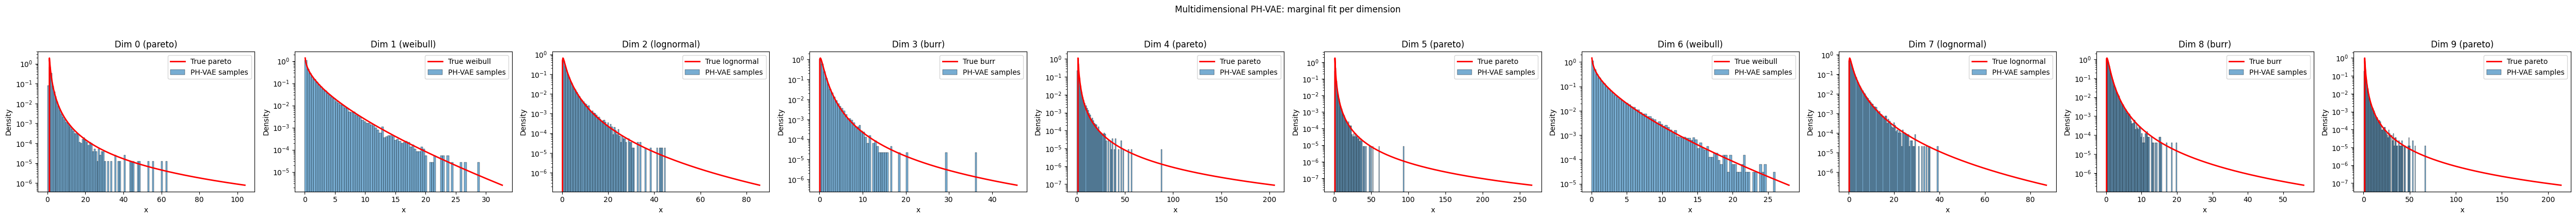

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# from scipy.stats import weibull_min, pareto, lognorm, burr12


# def true_pdf(x, dist_name, params):
#     if dist_name == "weibull":
#         return weibull_min.pdf(
#             x,
#             c=params["k"],
#             scale=params["lam"]
#         )

#     if dist_name == "pareto":
#         return pareto.pdf(
#             x,
#             b=params["a"],
#             scale=params["xm"]
#         )

#     if dist_name == "lognormal":
#         return lognorm.pdf(
#             x,
#             s=params["sigma"],
#             scale=params["scale"]
#         )

#     if dist_name == "burr":
#         return burr12.pdf(
#             x,
#             c=params["c"],
#             d=params["d"],
#             scale=params["scale"]
#         )

#     raise ValueError(f"Unknown distribution: {dist_name}")



# dims = range(dim)          
# N = 100_000

# model10d.eval()
# device = next(model10d.parameters()).device


# with torch.no_grad():
#     z = torch.randn(N, model10d.latent_dim, device=device)
#     alphas, As, ts = model10d.decode_params(z)

# plt.figure(figsize=(5 * len(dims), 4))


# for i, j in enumerate(dims):

#     # PH-VAE samples (dimension j)
#     ph_samples_j = ph_sample_batch(
#         alphas[j], As[j], ts[j]
#     ).cpu().numpy()

#     # True data samples
#     data_j = x10[:, j].cpu().numpy()

#     # True marginal info
#     dist_name = meta10["dist_names"][j]
#     dist_param = meta10["dist_params"][j]

#     # Grid
#     x_max = max(ph_samples_j.max(), data_j.max())
#     x_grid = np.linspace(0, x_max, 500)

#     pdf_true = true_pdf(x_grid, dist_name, dist_param)

#     # Plot
#     plt.subplot(1, len(dims), i + 1)
#     sns.histplot(
#         ph_samples_j,
#         bins=80,
#         stat="density",
#         alpha=0.6,
#         label="PH-VAE samples"
#     )
#     plt.plot(
#         x_grid,
#         pdf_true,
#         "r-",
#         lw=2,
#         label=f"True {dist_name}"
#     )

#     plt.yscale("log")
#     plt.xlabel("x")
#     plt.title(f"Dim {j} ({dist_name})")
#     if i == 0:
#         plt.ylabel("Density")
#     plt.legend()

# plt.suptitle(
#     "Multidimensional PH-VAE: marginal fit per dimension",
#     y=1.05
# )
# plt.tight_layout()
# plt.show()


In [ ]:
# results = []

# model10d.eval()
# device = next(model10d.parameters()).device

# N = 200_000
# with torch.no_grad():
#     z = torch.randn(N, model10d.latent_dim, device=device)
#     alphas, As, ts = model10d.decode_params(z)

# for j in range(x10.shape[1]):

#     # PH-VAE samples
#     ph_samples_j = ph_sample_batch(
#         alphas[j], As[j], ts[j]
#     ).cpu().numpy()

#     # True marginal info
#     dist_name = meta10["dist_names"][j]
#     params = meta10["dist_params"][j]

#     # Metrics
#     ks_tail = ks_tail_conditional(
#         ph_samples_j,
#         dist_name,
#         params,
#         q=0.95
#     )

#     Q99_true = true_ppf(0.99, dist_name, params)
#     Q99_model = np.quantile(ph_samples_j, 0.99)

#     abs_err = abs(Q99_model - Q99_true)
#     rel_err = abs_err / Q99_true

#     results.append({
#         "Dim": j,
#         "Distribution": dist_name,
#         "KS_tail@0.95": ks_tail,
#         "Q99_abs_err": abs_err,
#         "Q99_rel_err": rel_err,
#     })

# df_results = pd.DataFrame(results)
# df_results


,Dim,Distribution,KS_tail@0.95,Q99_abs_err,Q99_rel_err
0,0,pareto,0.058709,0.605772,0.074682
1,1,weibull,0.037443,0.637157,0.071904
2,2,lognormal,0.019796,0.458247,0.044749
3,3,burr,0.030509,0.264676,0.065190
4,4,pareto,0.024779,1.097237,0.135273
5,5,pareto,0.014731,0.075404,0.009296
6,6,weibull,0.025635,0.474412,0.053538
7,7,lognormal,0.017212,0.234260,0.022876
8,8,burr,0.020798,0.058054,0.014299
9,9,pareto,0.029638,0.230378,0.028402


# Real MutliVariate data

In [13]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader

# If needed:
# pip install yfinance
import yfinance as yf


tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "JPM"]
start = "2010-01-01"
end   = None  # up to latest
df = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
prices = df["Close"].dropna()  # [T,5]
prices = prices.asfreq("B").ffill().dropna()  # business-day grid (optional)


# log returns
rets = np.log(prices).diff().dropna() 

X_abs  = np.abs(rets.values)                     # |r|
X_loss = np.maximum(-rets.values, 0.0)           

X = X_abs  


scale = 100.0
X = X * scale

x = torch.tensor(X, dtype=torch.float32)
loader_finance = DataLoader(TensorDataset(x), batch_size=512, shuffle=True, drop_last=False)

print("Data shape:", x.shape)
print("Min/mean/max:", x.min().item(), x.mean().item(), x.max().item())


Data shape: torch.Size([4234, 5])
Min/mean/max: 0.0 1.1946176290512085 16.562000274658203


In [ ]:
# 5d 
dim =x.shape[1]

model_finance = phVAE.MultiDimPHVAE(input_dim=dim, latent_dim=20, n_phases=15)
train_phvae(
    model_finance,
    loader_finance,
    epochs=100,
    learning_rate=1e-3,
    beta=1,           
    grad_clip=1.0,
    save_every=10,
    reduce_lr=False,
    model_type='PH-VAE-MULTI'
)

In [84]:
import numpy as np
import torch
import itertools
from scipy.stats import kendalltau


model_finance.eval()
device = next(model_finance.parameters()).device

N_gen = min(200_000, x.shape[0])  # keep comparable size

with torch.no_grad():
    z = torch.randn(N_gen, model_finance.latent_dim, device=device)
    alphas, As, ts = model_finance.decode_params(z)
    x_gen = ph_sample_multidim(alphas, As, ts).cpu().numpy()

x_real = x[:N_gen].cpu().numpy()
k = x_real.shape[1]


Xr = np.log1p(x_real)
Xg = np.log1p(x_gen)

corr_real = np.corrcoef(Xr, rowvar=False)
corr_gen  = np.corrcoef(Xg, rowvar=False)

corr_error = np.linalg.norm(corr_real - corr_gen, ord="fro")


tau_errs = []
for i, j in itertools.combinations(range(k), 2):
    tau_r, _ = kendalltau(x_real[:, i], x_real[:, j])
    tau_g, _ = kendalltau(x_gen[:, i],  x_gen[:, j])
    if np.isfinite(tau_r) and np.isfinite(tau_g):
        tau_errs.append(abs(tau_r - tau_g))

kendall_tau_error = np.mean(tau_errs)

qs = [0.95, 0.97, 0.99]
tail_results = {}

for q in qs:
    abs_pair_errors = []
    probs_real = []
    probs_gen  = []

    for i, j in itertools.combinations(range(k), 2):
        qi_r = np.quantile(x_real[:, i], q)
        qj_r = np.quantile(x_real[:, j], q)
        qi_g = np.quantile(x_gen[:, i],  q)
        qj_g = np.quantile(x_gen[:, j],  q)

        p_real = np.mean((x_real[:, i] > qi_r) & (x_real[:, j] > qj_r))
        p_gen  = np.mean((x_gen[:, i]  > qi_g) & (x_gen[:, j]  > qj_g))

        probs_real.append(p_real)
        probs_gen.append(p_gen)

        abs_pair_errors.append(abs(p_gen - p_real))

    tail_results[q] = {
        "real": np.mean(probs_real),
        "gen":  np.mean(probs_gen),
        "abs_error": np.mean(abs_pair_errors),
    }


print("=== Financial returns (5 assets) ===")
print(f"Correlation error (log1p, Frobenius): {corr_error:.4f}")
print(f"Mean Kendall τ error:                {kendall_tau_error:.4f}")
print("\nTail co-exceedance (avg over pairs):")
for q, v in tail_results.items():
    print(
        f"  q={q:.2f} | "
        f"real={v['real']:.4e} | "
        f"gen={v['gen']:.4e} | "
        f"abs_err={v['abs_error']:.2e}"
    )


=== Financial returns (5 assets) ===
Correlation error (log1p, Frobenius): 0.2482
Mean Kendall τ error:                0.0366

Tail co-exceedance (avg over pairs):
  q=0.95 | real=1.6993e-02 | gen=1.1050e-02 | abs_err=5.94e-03
  q=0.97 | real=8.2816e-03 | gen=4.7017e-03 | abs_err=3.58e-03
  q=0.99 | real=2.1480e-03 | gen=8.1146e-04 | abs_err=1.34e-03


In [ ]:

# Independent 1d for each
import torch
import numpy as np
import itertools

device = "cuda" if torch.cuda.is_available() else "cpu"

k = x.shape[1]          # number of dimensions
N_gen = 200_000          # number of generated samples


indep_models = []

for j in range(k):
    print(f"\nTraining independent PH-VAE for dim {j}")

    xj = x[:, j:j+1]  # shape [N,1]
    loader_j = make_loader(xj, batch_size=512)

    model_j = phVAE.FeedForwardPHVAE(
        input_dim=1,
        latent_dim=10,
        n_phases=15
    ).to(device)

    train_phvae(
        model_j,
        loader_j,
        epochs=100,
        learning_rate=1e-2,
        beta=1.0,
        grad_clip=1.0,
        reduce_lr=False,
        model_type="PH-VAE"
    )

    indep_models.append(model_j)

print("\nAll independent 1D models trained.")



In [71]:

samples_indep = []

with torch.no_grad():
    for j, model_j in enumerate(indep_models):
        model_j.eval()
        z = torch.randn(N_gen, model_j.latent_dim, device=device)
        alpha, A, t = model_j.decode_params(z)
        xj = ph_sample_batch(alpha, A, t).cpu().numpy()
        samples_indep.append(xj[:, None])

x_gen_indep = np.concatenate(samples_indep, axis=1)  # [N_gen, k]
x_real = x.cpu().numpy()[:N_gen]


#  correlation error (log1p)
Xr = np.log1p(x_real)
Xi = np.log1p(x_gen_indep)

corr_real = np.corrcoef(Xr, rowvar=False)
corr_indep = np.corrcoef(Xi, rowvar=False)

corr_error_indep = np.linalg.norm(corr_real - corr_indep, ord="fro")

#  Kendall tau error
from scipy.stats import kendalltau

tau_errs = []
for i, j in itertools.combinations(range(k), 2):
    tau_r, _ = kendalltau(x_real[:, i], x_real[:, j])
    tau_i, _ = kendalltau(x_gen_indep[:, i], x_gen_indep[:, j])
    if np.isfinite(tau_r) and np.isfinite(tau_i):
        tau_errs.append(abs(tau_r - tau_i))

kendall_tau_error_indep = np.mean(tau_errs)

#  tail co-exceedance
qs = [0.95, 0.97, 0.99]
tail_results = {}

for q in qs:
    abs_pair_errors = []
    probs_real = []
    probs_gen  = []

    for i, j in itertools.combinations(range(k), 2):
        qi_r = np.quantile(x_real[:, i], q)
        qj_r = np.quantile(x_real[:, j], q)
        qi_g = np.quantile(x_gen_indep[:, i],  q)
        qj_g = np.quantile(x_gen_indep[:, j],  q)

        p_real = np.mean((x_real[:, i] > qi_r) & (x_real[:, j] > qj_r))
        p_gen  = np.mean((x_gen_indep[:, i]  > qi_g) & (x_gen_indep[:, j]  > qj_g))

        probs_real.append(p_real)
        probs_gen.append(p_gen)

        abs_pair_errors.append(abs(p_gen - p_real))

    tail_results[q] = {
        "real": np.mean(probs_real),
        "gen":  np.mean(probs_gen),
        "abs_error": np.mean(abs_pair_errors),
    }

print("\n=== Independent PH baseline (per-dim) ===")
print(f"Correlation error (log1p, Frobenius): {corr_error_indep:.4f}")
print(f"Mean Kendall τ error:                {kendall_tau_error_indep:.4f}")
print("\nTail co-exceedance (avg over pairs):")
for q, v in tail_results.items():
    print(
        f"  q={q:.2f} | "
        f"real={v['real']:.4e} | "
        f"indep={v['gen']:.4e} | "
        f"abs_err={v['abs_error']:.2e}"
    )



=== Independent PH baseline (per-dim) ===
Correlation error (log1p, Frobenius): 1.8645
Mean Kendall τ error:                0.2667

Tail co-exceedance (avg over pairs):
  q=0.95 | real=1.6989e-02 | indep=2.5565e-03 | abs_err=1.44e-02
  q=0.97 | real=8.2796e-03 | indep=9.0100e-04 | abs_err=7.38e-03
  q=0.99 | real=2.1475e-03 | indep=1.0100e-04 | abs_err=2.05e-03


# VAE

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np


# ---------------------------
# Simple Gaussian VAE
# ---------------------------
class VAE(nn.Module):
    def __init__(self, input_dim=5, latent_dim=10, hidden_dim=32):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return self.fc_out(h)


    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


# ---------------------------
# Loss function
# ---------------------------
def vae_loss(x, x_hat, mu, logvar):
    recon = nn.functional.mse_loss(x_hat, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl


# ---------------------------
# Training loop
# ---------------------------
def train_vae(X, epochs=50, batch_size=1024, lr=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X = torch.tensor(X, dtype=torch.float32)
    dataset = TensorDataset(X)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = VAE(input_dim=X.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for (x,) in loader:
            x = x.to(device)
            optimizer.zero_grad()

            x_hat, mu, logvar = model(x)
            loss = vae_loss(x, x_hat, mu, logvar)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Loss: {total_loss / len(X):.4f}")

    return model


In [8]:
# X: numpy array of shape (N, 5)
vae = train_vae(x, epochs=2000)


NameError: name 'x' is not defined

In [ ]:
import numpy as np
import torch
from scipy.stats import kendalltau
import itertools

vae.eval()
device = next(vae.parameters()).device

N_gen = 200_000
latent_dim = 10  # must match training

with torch.no_grad():
    z = torch.randn(N_gen, latent_dim, device=device)
    x_gen = vae.decode(z).cpu().numpy()

x_real = x[:N_gen] if isinstance(x, np.ndarray) else x.cpu().numpy()[:N_gen]
k = x_real.shape[1]

Xr = np.log1p(x_real)
Xg = np.log1p(x_gen)

corr_real = np.corrcoef(Xr, rowvar=False)
corr_gen  = np.corrcoef(Xg, rowvar=False)
corr_error = np.linalg.norm(corr_real - corr_gen, ord="fro")

tau_errs = []
for i, j in itertools.combinations(range(k), 2):
    tau_r, _ = kendalltau(x_real[:, i], x_real[:, j])
    tau_g, _ = kendalltau(x_gen[:, i],  x_gen[:, j])
    if np.isfinite(tau_r) and np.isfinite(tau_g):
        tau_errs.append(abs(tau_r - tau_g))

kendall_tau_error = np.mean(tau_errs)
tau_errs = []
for i, j in itertools.combinations(range(k), 2):
    tau_r, _ = kendalltau(x_real[:, i], x_real[:, j])
    tau_g, _ = kendalltau(x_gen[:, i],  x_gen[:, j])
    if np.isfinite(tau_r) and np.isfinite(tau_g):
        tau_errs.append(abs(tau_r - tau_g))

kendall_tau_error = np.mean(tau_errs)
qs = [0.95, 0.97, 0.99]
tail_results = {}

for q in qs:
    abs_pair_errors = []
    probs_real = []
    probs_gen  = []

    for i, j in itertools.combinations(range(k), 2):
        qi_r = np.quantile(x_real[:, i], q)
        qj_r = np.quantile(x_real[:, j], q)

        p_real = np.mean((x_real[:, i] > qi_r) & (x_real[:, j] > qj_r))
        p_gen  = np.mean((x_gen[:,  i] > qi_r) & (x_gen[:,  j] > qj_r))

        probs_real.append(p_real)
        probs_gen.append(p_gen)
        abs_pair_errors.append(abs(p_gen - p_real))

        

    tail_results[q] = {
        "real": np.mean(probs_real),
        "gen":  np.mean(probs_gen),
        "abs_error": np.mean(abs_pair_errors),
    }
print("=== Dependence evaluation (Gaussian VAE) ===")
print(f"Correlation error (log1p, Frobenius): {corr_error:.4f}")
print(f"Mean Kendall τ error:                {kendall_tau_error:.4f}")
print("\nTail co-exceedance (avg over pairs):")
for q, v in tail_results.items():
    print(
        f"  q={q:.2f} | "
        f"real={v['real']:.4e} | "
        f"gen={v['gen']:.4e} | "
        f"abs_err={v['abs_error']:.2e}"
    )


=== Dependence evaluation (Gaussian VAE) ===
Correlation error (log1p, Frobenius): 1.1775
Mean Kendall τ error:                0.2639

Tail co-exceedance (avg over pairs):
  q=0.95 | real=1.6989e-02 | gen=1.4049e-02 | abs_err=2.94e-03
  q=0.97 | real=8.2796e-03 | gen=6.4060e-03 | abs_err=1.87e-03
  q=0.99 | real=2.1475e-03 | gen=7.6150e-04 | abs_err=1.39e-03


# S eeds

In [5]:
# 5-seed evaluation on synthetic 5D data (x5, meta5) for PH-VAE-MULTI
import numpy as np
import pandas as pd
import torch
import itertools
from scipy.stats import kendalltau


def dependence_metrics(x_real, x_gen, q=0.99):
    k = x_real.shape[1]
    Xr = np.log1p(x_real)
    Xg = np.log1p(x_gen)

    corr_real = np.corrcoef(Xr, rowvar=False)
    corr_gen = np.corrcoef(Xg, rowvar=False)
    corr_error = float(np.linalg.norm(corr_real - corr_gen, ord="fro"))

    tau_errs = []
    for i, j in itertools.combinations(range(k), 2):
        tau_r, _ = kendalltau(x_real[:, i], x_real[:, j])
        tau_g, _ = kendalltau(x_gen[:, i], x_gen[:, j])
        if np.isfinite(tau_r) and np.isfinite(tau_g):
            tau_errs.append(abs(tau_r - tau_g))
    kendall_tau_error = float(np.mean(tau_errs)) if tau_errs else np.nan

    abs_pair_errors = []
    for i, j in itertools.combinations(range(k), 2):
        qi = np.quantile(x_real[:, i], q)
        qj = np.quantile(x_real[:, j], q)
        p_real = np.mean((x_real[:, i] > qi) & (x_real[:, j] > qj))
        p_gen = np.mean((x_gen[:, i] > qi) & (x_gen[:, j] > qj))
        abs_pair_errors.append(abs(p_gen - p_real))
    tail_coex_abs_error = float(np.mean(abs_pair_errors)) if abs_pair_errors else np.nan

    return corr_error, kendall_tau_error, tail_coex_abs_error


def summary_stats(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    n = vals.size
    if n == 0:
        return np.nan, np.nan, np.nan, np.nan
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if n > 1 else 0.0
    ci = 1.96 * std / np.sqrt(n)
    return mean, std, float(mean - ci), float(mean + ci)


def all_finite(x):
    if torch.is_tensor(x):
        return bool(torch.isfinite(x).all().item())
    if isinstance(x, (list, tuple)):
        return all(all_finite(v) for v in x)
    arr = np.asarray(x)
    return bool(np.isfinite(arr).all())


SEEDS = [1, 1000, 34, 1111, 121]
Q_COEX = 0.99
N_GEN = min(x5.shape[0], 200_000)

# Same training settings as original x5 run
EPOCHS_PH_MULTI = 13
BATCH_SIZE = 1024
SAVE_EVERY = 10
LEARNING_RATE = 1e-2

x_real_5d = x5[:N_GEN].cpu().numpy()
loader5_multi = make_loader(x5, batch_size=BATCH_SIZE)

# Results from the 5 dedicated seed cells will be stored here.
rows_ph5 = []

def run_ph_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model_seed = phVAE.MultiDimPHVAE(input_dim=dim, latent_dim=10, n_phases=15)
    train_phvae(
        model_seed,
        loader5_multi,
        epochs=EPOCHS_PH_MULTI,
        learning_rate=LEARNING_RATE,
        beta=1,
        grad_clip=1.0,
        save_every=SAVE_EVERY,
        reduce_lr=False,
        model_type='PH-VAE-MULTI'
    )

    model_seed.eval()
    dev = next(model_seed.parameters()).device
    with torch.no_grad():
        z = torch.randn(N_GEN, model_seed.latent_dim, device=dev)
        alphas, As, ts = model_seed.decode_params(z)
        x_gen_ph_multi = ph_sample_multidim(alphas, As, ts).cpu().numpy()

    ok_ph = (
        all_finite(alphas)
        and all_finite(As)
        and all_finite(ts)
        and np.isfinite(x_gen_ph_multi).all()
        and np.all(x_gen_ph_multi >= 0)
    )

    if ok_ph:
        corr_e_ph, tau_e_ph, coex_e_ph = dependence_metrics(x_real_5d, x_gen_ph_multi, q=Q_COEX)
    else:
        corr_e_ph, tau_e_ph, coex_e_ph = np.nan, np.nan, np.nan

    row = {
        "seed": seed,
        "model": "PH-VAE-MULTI",
        "corr_error": corr_e_ph,
        "kendall_tau_error": tau_e_ph,
        "tail_coex_abs_error": coex_e_ph,
    }
    rows_ph5.append(row)

    print(
        f"seed={seed} | "
        f"PH corr={corr_e_ph:.4f}, tau={tau_e_ph:.4f}, coex={coex_e_ph:.3e}"
    )
    return row

print("Setup complete. Run the next 5 cells (one per seed), then the summary cell.")

Setup complete. Run the next 5 cells (one per seed), then the summary cell.


In [6]:
# Seed cell 1
run_ph_seed(1)

/home/hakimmics/myenv/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
Epoch 1/13:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/13: 100%|██████████| 79/79 [00:11<00:00,  7.14it/s]


Epoch 001 | Loss: 5.5700 | Recon: -4.9830 | KL: 0.5870 | Time/epoch: 11.06s


Epoch 2/13: 100%|██████████| 79/79 [00:12<00:00,  6.19it/s]


Epoch 002 | Loss: 4.8104 | Recon: -4.3540 | KL: 0.4564 | Time/epoch: 12.77s


...

Epoch 12/13: 100%|██████████| 79/79 [00:13<00:00,  5.98it/s]


Epoch 012 | Loss: 4.4726 | Recon: -3.4145 | KL: 1.0581 | Time/epoch: 13.22s


Epoch 13/13: 100%|██████████| 79/79 [00:14<00:00,  5.36it/s]


Epoch 013 | Loss: 4.4852 | Recon: -3.4312 | KL: 1.0540 | Time/epoch: 14.75s

Total training time: 184.61s (14.20s/epoch avg)
Mean time/epoch: 14.20 ± 1.48 s
seed=1 | PH corr=0.1625, tau=0.0189, coex=9.562e-04


{'seed': 1,
 'model': 'PH-VAE-MULTI',
 'corr_error': 0.16252284116565094,
 'kendall_tau_error': 0.018891870655739867,
 'tail_coex_abs_error': 0.0009562499999999999}

In [7]:
# Seed cell 1000
run_ph_seed(234)

Epoch 1/13: 100%|██████████| 79/79 [00:10<00:00,  7.56it/s]


Epoch 001 | Loss: 5.3902 | Recon: -5.0630 | KL: 0.3272 | Time/epoch: 10.46s


Epoch 2/13: 100%|██████████| 79/79 [00:12<00:00,  6.11it/s]


Epoch 002 | Loss: 4.7536 | Recon: -4.1450 | KL: 0.6085 | Time/epoch: 12.94s


Epoch 3/13: 100%|██████████| 79/79 [00:11<00:00,  6.70it/s]


...

Epoch 12/13: 100%|██████████| 79/79 [00:11<00:00,  6.75it/s]


Epoch 012 | Loss: 4.4793 | Recon: -3.4290 | KL: 1.0503 | Time/epoch: 11.70s


Epoch 13/13: 100%|██████████| 79/79 [00:10<00:00,  7.22it/s]


Epoch 013 | Loss: 4.4769 | Recon: -3.4241 | KL: 1.0528 | Time/epoch: 10.95s

Total training time: 164.01s (12.62s/epoch avg)
Mean time/epoch: 12.62 ± 1.53 s
seed=234 | PH corr=0.1844, tau=0.0319, coex=3.162e-04


{'seed': 234,
 'model': 'PH-VAE-MULTI',
 'corr_error': 0.1844485802260788,
 'kendall_tau_error': 0.03192085979589708,
 'tail_coex_abs_error': 0.0003162499999999999}

In [8]:
# Seed cell 34
run_ph_seed(233)

Epoch 1/13: 100%|██████████| 79/79 [00:11<00:00,  6.90it/s]


Epoch 001 | Loss: 31.9484 | Recon: -5.0937 | KL: 26.8548 | Time/epoch: 11.45s


Epoch 2/13: 100%|██████████| 79/79 [00:10<00:00,  7.33it/s]


Epoch 002 | Loss: 4.7878 | Recon: -4.1113 | KL: 0.6765 | Time/epoch: 10.78s


Epoch 3/13: 100%|██████████| 79/79 [00:12<00:00,  6.08it/s]


...

Epoch 12/13: 100%|██████████| 79/79 [00:11<00:00,  6.67it/s]


Epoch 012 | Loss: 4.4697 | Recon: -3.4169 | KL: 1.0527 | Time/epoch: 11.84s


Epoch 13/13: 100%|██████████| 79/79 [00:10<00:00,  7.30it/s]


Epoch 013 | Loss: 4.4568 | Recon: -3.4005 | KL: 1.0563 | Time/epoch: 10.82s

Total training time: 147.65s (11.36s/epoch avg)
Mean time/epoch: 11.36 ± 0.88 s
seed=233 | PH corr=0.1868, tau=0.0294, coex=4.337e-04


{'seed': 233,
 'model': 'PH-VAE-MULTI',
 'corr_error': 0.1868073514127875,
 'kendall_tau_error': 0.02944034134388778,
 'tail_coex_abs_error': 0.00043375}

In [9]:
# Seed cell 1111
run_ph_seed(1111)

Epoch 1/13: 100%|██████████| 79/79 [00:12<00:00,  6.35it/s]


Epoch 001 | Loss: 5.5204 | Recon: -5.1821 | KL: 0.3383 | Time/epoch: 12.45s


Epoch 2/13: 100%|██████████| 79/79 [00:12<00:00,  6.41it/s]


Epoch 002 | Loss: 4.9280 | Recon: -4.6104 | KL: 0.3177 | Time/epoch: 12.33s


Epoch 3/13: 100%|██████████| 79/79 [00:11<00:00,  7.06it/s]


...

Epoch 12/13: 100%|██████████| 79/79 [00:17<00:00,  4.42it/s]


Epoch 012 | Loss: 4.5074 | Recon: -3.4720 | KL: 1.0354 | Time/epoch: 17.86s


Epoch 13/13: 100%|██████████| 79/79 [00:16<00:00,  4.92it/s]


Epoch 013 | Loss: 4.4885 | Recon: -3.4505 | KL: 1.0380 | Time/epoch: 16.06s

Total training time: 187.92s (14.46s/epoch avg)
Mean time/epoch: 14.45 ± 3.03 s
seed=1111 | PH corr=0.1933, tau=0.0272, coex=3.225e-04


{'seed': 1111,
 'model': 'PH-VAE-MULTI',
 'corr_error': 0.19329948439693687,
 'kendall_tau_error': 0.027238874731354064,
 'tail_coex_abs_error': 0.00032250000000000014}

In [10]:
# Seed cell 121
run_ph_seed(12121)

Epoch 1/13: 100%|██████████| 79/79 [00:17<00:00,  4.45it/s]


Epoch 001 | Loss: 5.2342 | Recon: -5.0621 | KL: 0.1721 | Time/epoch: 17.74s


Epoch 2/13: 100%|██████████| 79/79 [00:19<00:00,  4.07it/s]


Epoch 002 | Loss: 4.8701 | Recon: -4.5172 | KL: 0.3529 | Time/epoch: 19.42s


Epoch 3/13: 100%|██████████| 79/79 [00:16<00:00,  4.91it/s]


...

Epoch 12/13: 100%|██████████| 79/79 [00:13<00:00,  5.85it/s]


Epoch 012 | Loss: 4.4775 | Recon: -3.4459 | KL: 1.0315 | Time/epoch: 13.52s


Epoch 13/13: 100%|██████████| 79/79 [00:12<00:00,  6.52it/s]


Epoch 013 | Loss: 4.4699 | Recon: -3.4213 | KL: 1.0485 | Time/epoch: 12.11s

Total training time: 208.13s (16.01s/epoch avg)
Mean time/epoch: 16.01 ± 2.18 s
seed=12121 | PH corr=0.1498, tau=0.0203, coex=7.925e-04


{'seed': 12121,
 'model': 'PH-VAE-MULTI',
 'corr_error': 0.14975356587426908,
 'kendall_tau_error': 0.020327988261120433,
 'tail_coex_abs_error': 0.0007925}

In [11]:
# Summary cell: run this after executing the 5 seed cells
if len(rows_ph5) == 0:
    print("No seed results found yet. Run the five seed cells first.")
else:
    df_seed_5d = pd.DataFrame(rows_ph5)
    df_seed_5d = df_seed_5d.sort_values("seed").reset_index(drop=True)
    print("\nPer-seed results (5D synthetic, PH-VAE-MULTI):")
    print(df_seed_5d.to_string(index=False))

    summary_rows = []
    for metric in ["corr_error", "kendall_tau_error", "tail_coex_abs_error"]:
        mean, std, lo, hi = summary_stats(df_seed_5d[metric].values)
        summary_rows.append({
            "model": "PH-VAE-MULTI",
            "metric": metric,
            "mean±std": f"{mean:.6f} ± {std:.6f}" if np.isfinite(mean) else "nan ± nan",
            "95% CI": f"[{lo:.6f}, {hi:.6f}]" if np.isfinite(lo) else "[nan, nan]",
        })

    df_summary_5d = pd.DataFrame(summary_rows)
    print("\nSummary across available seeds (synthetic 5D, PH-VAE-MULTI):")
    print(df_summary_5d.to_string(index=False))


Per-seed results (5D synthetic, PH-VAE-MULTI):
 seed        model  corr_error  kendall_tau_error  tail_coex_abs_error
    1 PH-VAE-MULTI    0.162523           0.018892             0.000956
  233 PH-VAE-MULTI    0.186807           0.029440             0.000434
  234 PH-VAE-MULTI    0.184449           0.031921             0.000316
 1111 PH-VAE-MULTI    0.193299           0.027239             0.000323
12121 PH-VAE-MULTI    0.149754           0.020328             0.000793

Summary across available seeds (synthetic 5D, PH-VAE-MULTI):
       model              metric            mean±std               95% CI
PH-VAE-MULTI          corr_error 0.175366 ± 0.018412 [0.159228, 0.191505]
PH-VAE-MULTI   kendall_tau_error 0.025564 ± 0.005705 [0.020564, 0.030564]
PH-VAE-MULTI tail_coex_abs_error 0.000564 ± 0.000293 [0.000308, 0.000821]


In [21]:
# 5-seed evaluation on real financial data for PH-VAE, independent PH, and classic VAE
import numpy as np
import pandas as pd
import torch
import itertools
from scipy.stats import kendalltau

if 'x' not in globals():
    raise ValueError("Real financial tensor x was not found. Run the real-data preparation cell first.")

if '_dependence_metrics' not in globals():
    def _dependence_metrics(x_real, x_gen, q=0.99):
        k = x_real.shape[1]
        Xr = np.log1p(x_real)
        Xg = np.log1p(x_gen)

        corr_real = np.corrcoef(Xr, rowvar=False)
        corr_gen = np.corrcoef(Xg, rowvar=False)
        corr_error = float(np.linalg.norm(corr_real - corr_gen, ord="fro"))

        tau_errs = []
        for i, j in itertools.combinations(range(k), 2):
            tau_r, _ = kendalltau(x_real[:, i], x_real[:, j])
            tau_g, _ = kendalltau(x_gen[:, i], x_gen[:, j])
            if np.isfinite(tau_r) and np.isfinite(tau_g):
                tau_errs.append(abs(tau_r - tau_g))
        kendall_tau_error = float(np.mean(tau_errs)) if tau_errs else np.nan

        abs_pair_errors = []
        for i, j in itertools.combinations(range(k), 2):
            qi = np.quantile(x_real[:, i], q)
            qj = np.quantile(x_real[:, j], q)
            p_real = np.mean((x_real[:, i] > qi) & (x_real[:, j] > qj))
            p_gen = np.mean((x_gen[:, i] > qi) & (x_gen[:, j] > qj))
            abs_pair_errors.append(abs(p_gen - p_real))
        tail_coex_abs_error = float(np.mean(abs_pair_errors)) if abs_pair_errors else np.nan

        return corr_error, kendall_tau_error, tail_coex_abs_error

if '_summary_stats' not in globals():
    def _summary_stats(vals):
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        n = vals.size
        if n == 0:
            return np.nan, np.nan, np.nan, np.nan
        mean = float(np.mean(vals))
        std = float(np.std(vals, ddof=1)) if n > 1 else 0.0
        ci = 1.96 * std / np.sqrt(n)
        return mean, std, float(mean - ci), float(mean + ci)

SEEDS = [345, 234, 224, 2344, 3453454]
Q_COEX = 0.99
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x_tensor = x5 if isinstance(x5, torch.Tensor) else torch.tensor(x5, dtype=torch.float32)
x_tensor = x_tensor.to("cpu")
x_real = x_tensor.cpu().numpy()

# Speed knobs
FAST_MODE = True
N_GEN = min(30_000 if FAST_MODE else 200_000, x_real.shape[0])
x_real_eval = x_real[:N_GEN]
k = x_real_eval.shape[1]
BATCH_SIZE = 2048 if FAST_MODE else 512
EPOCHS_PH = 20 if FAST_MODE else 100
EPOCHS_INDEP = 20 if FAST_MODE else 100
EPOCHS_VAE = 50

# Toggle models without breaking indexing/printing
RUN_PH = False
RUN_INDEP = False
RUN_VAE = True

results = {
    "PH-VAE": {"corr_error": [], "kendall_tau_error": [], "tail_coex_abs_error": []},
    "Independent PH": {"corr_error": [], "kendall_tau_error": [], "tail_coex_abs_error": []},
    "Classic VAE": {"corr_error": [], "kendall_tau_error": [], "tail_coex_abs_error": []},
}

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    if RUN_PH:
        loader_fin = make_loader(x_tensor, batch_size=BATCH_SIZE)
        model_ph = phVAE.MultiDimPHVAE(input_dim=k, latent_dim=20, n_phases=15).to(device)
        train_phvae(
            model_ph,
            loader_fin,
            epochs=EPOCHS_PH,
            learning_rate=1e-3,
            beta=1.0,
            grad_clip=1.0,
            save_every=10_000,
            reduce_lr=False,
            model_type='PH-VAE-MULTI'
        )
        model_ph.eval()
        with torch.no_grad():
            z = torch.randn(N_GEN, model_ph.latent_dim, device=device)
            alphas, As, ts = model_ph.decode_params(z)
            x_gen_ph = ph_sample_multidim(alphas, As, ts).cpu().numpy()
        c, t, coex = _dependence_metrics(x_real_eval, x_gen_ph, q=Q_COEX)
        results["PH-VAE"]["corr_error"].append(c)
        results["PH-VAE"]["kendall_tau_error"].append(t)
        results["PH-VAE"]["tail_coex_abs_error"].append(coex)
    else:
        results["PH-VAE"]["corr_error"].append(np.nan)
        results["PH-VAE"]["kendall_tau_error"].append(np.nan)
        results["PH-VAE"]["tail_coex_abs_error"].append(np.nan)

    if RUN_INDEP:
        samples_indep = []
        for j in range(k):
            xj = x_tensor[:, j:j+1]
            loader_j = make_loader(xj, batch_size=BATCH_SIZE)
            model_j = phVAE.FeedForwardPHVAE(input_dim=1, latent_dim=10, n_phases=15).to(device)
            train_phvae(
                model_j,
                loader_j,
                epochs=EPOCHS_INDEP,
                learning_rate=1e-2,
                beta=1.0,
                grad_clip=1.0,
                save_every=10_000,
                reduce_lr=False,
                model_type="PH-VAE"
            )
            model_j.eval()
            with torch.no_grad():
                z = torch.randn(N_GEN, model_j.latent_dim, device=device)
                alpha, A, tvec = model_j.decode_params(z)
                xj_gen = ph_sample_batch(alpha, A, tvec).cpu().numpy()
                samples_indep.append(xj_gen[:, None])
        x_gen_indep = np.concatenate(samples_indep, axis=1)
        c, t, coex = _dependence_metrics(x_real_eval, x_gen_indep, q=Q_COEX)
        results["Independent PH"]["corr_error"].append(c)
        results["Independent PH"]["kendall_tau_error"].append(t)
        results["Independent PH"]["tail_coex_abs_error"].append(coex)
    else:
        results["Independent PH"]["corr_error"].append(np.nan)
        results["Independent PH"]["kendall_tau_error"].append(np.nan)
        results["Independent PH"]["tail_coex_abs_error"].append(np.nan)

    if RUN_VAE:
        x_np = x_real.copy()
        vae_model = train_vae(x_np, epochs=EPOCHS_VAE, batch_size=2048 if FAST_MODE else 1024, lr=1e-2)
        vae_model.eval()
        latent_dim = vae_model.fc_mu.out_features
        with torch.no_grad():
            z = torch.randn(N_GEN, latent_dim, device=next(vae_model.parameters()).device)
            x_gen_vae = vae_model.decode(z).cpu().numpy()
        c, t, coex = _dependence_metrics(x_real_eval, x_gen_vae, q=Q_COEX)
        results["Classic VAE"]["corr_error"].append(c)
        results["Classic VAE"]["kendall_tau_error"].append(t)
        results["Classic VAE"]["tail_coex_abs_error"].append(coex)
    else:
        results["Classic VAE"]["corr_error"].append(np.nan)
        results["Classic VAE"]["kendall_tau_error"].append(np.nan)
        results["Classic VAE"]["tail_coex_abs_error"].append(np.nan)

    print(
        f"seed={seed} | "
        f"PH corr={results['PH-VAE']['corr_error'][-1]:.4f}, tau={results['PH-VAE']['kendall_tau_error'][-1]:.4f}, coex={results['PH-VAE']['tail_coex_abs_error'][-1]:.3e} | "
        f"Ind corr={results['Independent PH']['corr_error'][-1]:.4f}, tau={results['Independent PH']['kendall_tau_error'][-1]:.4f}, coex={results['Independent PH']['tail_coex_abs_error'][-1]:.3e} | "
        f"VAE corr={results['Classic VAE']['corr_error'][-1]:.4f}, tau={results['Classic VAE']['kendall_tau_error'][-1]:.4f}, coex={results['Classic VAE']['tail_coex_abs_error'][-1]:.3e}"
    )

summary_rows = []
for model_name, d in results.items():
    for metric_name in ["corr_error", "kendall_tau_error", "tail_coex_abs_error"]:
        mean, std, lo, hi = _summary_stats(d[metric_name])
        summary_rows.append({
            "model": model_name,
            "metric": metric_name,
            "mean±std": f"{mean:.6f} ± {std:.6f}" if np.isfinite(mean) else "nan ± nan",
            "95% CI": f"[{lo:.6f}, {hi:.6f}]" if np.isfinite(lo) else "[nan, nan]",
        })

df_fin_summary = pd.DataFrame(summary_rows)
print("\nSummary across 5 seeds (real financial data):")
print(df_fin_summary.to_string(index=False))

Epoch 000 | Loss: 14.0306
Epoch 010 | Loss: 4.4475
Epoch 020 | Loss: 4.2011
Epoch 030 | Loss: 4.0869
Epoch 040 | Loss: 4.0432


/tmp/ipykernel_1664/3623883801.py:15: RuntimeWarning: invalid value encountered in log1p
  Xg = np.log1p(x_gen)


seed=345 | PH corr=nan, tau=nan, coex=nan | Ind corr=nan, tau=nan, coex=nan | VAE corr=nan, tau=0.0999, coex=1.353e-03
Epoch 000 | Loss: 4409.0069
Epoch 010 | Loss: 4.9331
Epoch 020 | Loss: 4.4375
Epoch 030 | Loss: 5.1316
Epoch 040 | Loss: 4.1977
seed=234 | PH corr=nan, tau=nan, coex=nan | Ind corr=nan, tau=nan, coex=nan | VAE corr=0.4353, tau=0.0884, coex=1.563e-03
Epoch 000 | Loss: 45.4109
Epoch 010 | Loss: 4.5625
Epoch 020 | Loss: 6.2122
Epoch 030 | Loss: 5.5734
Epoch 040 | Loss: 4.6829
seed=224 | PH corr=nan, tau=nan, coex=nan | Ind corr=nan, tau=nan, coex=nan | VAE corr=0.4262, tau=0.0766, coex=1.687e-03
Epoch 000 | Loss: 16.3580
Epoch 010 | Loss: 4.3744
Epoch 020 | Loss: 4.1197
Epoch 030 | Loss: 4.0010
Epoch 040 | Loss: 4.1407
seed=2344 | PH corr=nan, tau=nan, coex=nan | Ind corr=nan, tau=nan, coex=nan | VAE corr=0.5485, tau=0.1216, coex=1.610e-03
Epoch 000 | Loss: 21364.3723
Epoch 010 | Loss: 5.2961
Epoch 020 | Loss: 4.6111
Epoch 030 | Loss: 5.6755
Epoch 040 | Loss: 5.0211
seed=

In [23]:
# 5-seed evaluation on real financial data for PH-VAE-MULTI (setup)
import numpy as np
import pandas as pd
import torch

if 'x' not in globals():
    raise ValueError("Real financial tensor x was not found. Run the real-data preparation cells first.")

if 'summary_stats' not in globals():
    def summary_stats(vals):
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        n = vals.size
        if n == 0:
            return np.nan, np.nan, np.nan, np.nan
        mean = float(np.mean(vals))
        std = float(np.std(vals, ddof=1)) if n > 1 else 0.0
        ci = 1.96 * std / np.sqrt(n)
        return mean, std, float(mean - ci), float(mean + ci)

if 'all_finite' not in globals():
    def all_finite(v):
        if torch.is_tensor(v):
            return bool(torch.isfinite(v).all().item())
        if isinstance(v, (list, tuple)):
            return all(all_finite(z) for z in v)
        arr = np.asarray(v)
        return bool(np.isfinite(arr).all())

if 'dependence_metrics' not in globals():
    import itertools
    from scipy.stats import kendalltau

    def dependence_metrics(x_real, x_gen, q=0.99):
        k = x_real.shape[1]
        Xr = np.log1p(x_real)
        Xg = np.log1p(x_gen)

        corr_real = np.corrcoef(Xr, rowvar=False)
        corr_gen = np.corrcoef(Xg, rowvar=False)
        corr_error = float(np.linalg.norm(corr_real - corr_gen, ord='fro'))

        tau_errs = []
        for i, j in itertools.combinations(range(k), 2):
            tau_r, _ = kendalltau(x_real[:, i], x_real[:, j])
            tau_g, _ = kendalltau(x_gen[:, i], x_gen[:, j])
            if np.isfinite(tau_r) and np.isfinite(tau_g):
                tau_errs.append(abs(tau_r - tau_g))
        kendall_tau_error = float(np.mean(tau_errs)) if tau_errs else np.nan

        abs_pair_errors = []
        for i, j in itertools.combinations(range(k), 2):
            qi = np.quantile(x_real[:, i], q)
            qj = np.quantile(x_real[:, j], q)
            p_real = np.mean((x_real[:, i] > qi) & (x_real[:, j] > qj))
            p_gen = np.mean((x_gen[:, i] > qi) & (x_gen[:, j] > qj))
            abs_pair_errors.append(abs(p_gen - p_real))
        tail_coex_abs_error = float(np.mean(abs_pair_errors)) if abs_pair_errors else np.nan

        return corr_error, kendall_tau_error, tail_coex_abs_error

SEEDS_FIN = [0, 1, 2, 3, 4]
Q_COEX_FIN = 0.99
N_GEN_FIN = min(200_000, x.shape[0])

EPOCHS_PH_FIN = 100
BATCH_SIZE_FIN = 512
SAVE_EVERY_FIN = 10
LEARNING_RATE_FIN = 1e-3

x_real_fin = x[:N_GEN_FIN].cpu().numpy()
loader_fin_multi = make_loader(x, batch_size=BATCH_SIZE_FIN)
rows_ph5_fin = []

def run_ph_seed_fin(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model_seed = phVAE.MultiDimPHVAE(input_dim=x.shape[1], latent_dim=20, n_phases=15)
    train_phvae(
        model_seed,
        loader_fin_multi,
        epochs=EPOCHS_PH_FIN,
        learning_rate=LEARNING_RATE_FIN,
        beta=1,
        grad_clip=1.0,
        save_every=SAVE_EVERY_FIN,
        reduce_lr=False,
        model_type='PH-VAE-MULTI'
    )

    model_seed.eval()
    dev = next(model_seed.parameters()).device
    with torch.no_grad():
        z = torch.randn(N_GEN_FIN, model_seed.latent_dim, device=dev)
        alphas, As, ts = model_seed.decode_params(z)
        x_gen_fin = ph_sample_multidim(alphas, As, ts).cpu().numpy()

    ok = (
        all_finite(alphas)
        and all_finite(As)
        and all_finite(ts)
        and np.isfinite(x_gen_fin).all()
        and np.all(x_gen_fin >= 0)
    )

    if ok:
        corr_e, tau_e, coex_e = dependence_metrics(x_real_fin, x_gen_fin, q=Q_COEX_FIN)
    else:
        corr_e, tau_e, coex_e = np.nan, np.nan, np.nan

    row = {
        'seed': seed,
        'model': 'PH-VAE-MULTI',
        'corr_error': corr_e,
        'kendall_tau_error': tau_e,
        'tail_coex_abs_error': coex_e,
    }
    rows_ph5_fin.append(row)

    print(f"seed={seed} | PH corr={corr_e:.4f}, tau={tau_e:.4f}, coex={coex_e:.3e}")
    return row

print('Setup complete. Run the next 5 real-data seed cells, then the summary cell.')

Setup complete. Run the next 5 real-data seed cells, then the summary cell.


In [24]:
# Real-data seed cell 0
run_ph_seed_fin(1)

Epoch 1/100: 100%|██████████| 9/9 [00:00<00:00, 12.07it/s]


Epoch 001 | Loss: 6.0527 | Recon: -5.8905 | KL: 0.1622 | Time/epoch: 0.75s


Epoch 2/100: 100%|██████████| 9/9 [00:00<00:00, 12.84it/s]


Epoch 002 | Loss: 5.8253 | Recon: -5.8003 | KL: 0.0250 | Time/epoch: 0.70s


Epoch 3/100: 100%|██████████| 9/9 [00:00<00:00, 12.21it/s]


...

Epoch 99/100: 100%|██████████| 9/9 [00:01<00:00,  4.61it/s]


Epoch 099 | Loss: 4.1628 | Recon: -3.2815 | KL: 0.8813 | Time/epoch: 1.96s


Epoch 100/100: 100%|██████████| 9/9 [00:02<00:00,  4.28it/s]


Epoch 100 | Loss: 4.1563 | Recon: -3.2342 | KL: 0.9221 | Time/epoch: 2.11s

Total training time: 159.83s (1.60s/epoch avg)
Mean time/epoch: 1.60 ± 0.47 s
seed=1 | PH corr=0.2245, tau=0.0306, coex=1.630e-03


{'seed': 1,
 'model': 'PH-VAE-MULTI',
 'corr_error': 0.22447597087730203,
 'kendall_tau_error': 0.030631158910658308,
 'tail_coex_abs_error': 0.0016296646197449221}

In [25]:
# Real-data seed cell 1
run_ph_seed_fin(234)

Epoch 1/100: 100%|██████████| 9/9 [00:01<00:00,  6.09it/s]


Epoch 001 | Loss: 5.9857 | Recon: -5.8760 | KL: 0.1097 | Time/epoch: 1.48s


Epoch 2/100: 100%|██████████| 9/9 [00:01<00:00,  7.45it/s]


Epoch 002 | Loss: 5.8266 | Recon: -5.8019 | KL: 0.0248 | Time/epoch: 1.21s


Epoch 3/100: 100%|██████████| 9/9 [00:01<00:00,  5.62it/s]


...

Epoch 99/100: 100%|██████████| 9/9 [00:02<00:00,  3.83it/s]


Epoch 099 | Loss: 4.1213 | Recon: -3.2391 | KL: 0.8822 | Time/epoch: 2.36s


Epoch 100/100: 100%|██████████| 9/9 [00:02<00:00,  4.47it/s]


Epoch 100 | Loss: 4.1467 | Recon: -3.2636 | KL: 0.8831 | Time/epoch: 2.02s

Total training time: 173.19s (1.73s/epoch avg)
Mean time/epoch: 1.73 ± 0.41 s
seed=234 | PH corr=0.1952, tau=0.0350, coex=1.086e-03


{'seed': 234,
 'model': 'PH-VAE-MULTI',
 'corr_error': 0.1952079005818424,
 'kendall_tau_error': 0.03501657953291171,
 'tail_coex_abs_error': 0.001086443079829948}

In [26]:
# Real-data seed cell 2
run_ph_seed_fin(233)

Epoch 1/100: 100%|██████████| 9/9 [00:01<00:00,  5.90it/s]


Epoch 001 | Loss: 6.0116 | Recon: -5.8835 | KL: 0.1281 | Time/epoch: 1.53s


Epoch 2/100: 100%|██████████| 9/9 [00:01<00:00,  7.61it/s]


Epoch 002 | Loss: 5.8388 | Recon: -5.8138 | KL: 0.0250 | Time/epoch: 1.19s


Epoch 3/100: 100%|██████████| 9/9 [00:01<00:00,  7.20it/s]


...

Epoch 99/100: 100%|██████████| 9/9 [00:01<00:00,  5.11it/s]


Epoch 099 | Loss: 4.1280 | Recon: -3.2358 | KL: 0.8922 | Time/epoch: 1.76s


Epoch 100/100: 100%|██████████| 9/9 [00:01<00:00,  4.54it/s]


Epoch 100 | Loss: 4.1118 | Recon: -3.2295 | KL: 0.8824 | Time/epoch: 1.99s

Total training time: 170.74s (1.71s/epoch avg)
Mean time/epoch: 1.71 ± 0.43 s
seed=233 | PH corr=0.3147, tau=0.0454, coex=1.063e-03


{'seed': 233,
 'model': 'PH-VAE-MULTI',
 'corr_error': 0.31471721744975906,
 'kendall_tau_error': 0.0454150659662468,
 'tail_coex_abs_error': 0.0010628247520075578}

In [27]:
# Real-data seed cell 3
run_ph_seed_fin(1111)

Epoch 1/100: 100%|██████████| 9/9 [00:01<00:00,  7.65it/s]


Epoch 001 | Loss: 6.0064 | Recon: -5.8788 | KL: 0.1276 | Time/epoch: 1.18s


Epoch 2/100: 100%|██████████| 9/9 [00:01<00:00,  8.46it/s]


Epoch 002 | Loss: 5.8331 | Recon: -5.8123 | KL: 0.0207 | Time/epoch: 1.07s


Epoch 3/100: 100%|██████████| 9/9 [00:01<00:00,  7.51it/s]


...

Epoch 99/100: 100%|██████████| 9/9 [00:02<00:00,  3.98it/s]


Epoch 099 | Loss: 4.1297 | Recon: -3.2305 | KL: 0.8992 | Time/epoch: 2.26s


Epoch 100/100: 100%|██████████| 9/9 [00:02<00:00,  3.56it/s]


Epoch 100 | Loss: 4.1343 | Recon: -3.2321 | KL: 0.9022 | Time/epoch: 2.53s

Total training time: 190.94s (1.91s/epoch avg)
Mean time/epoch: 1.91 ± 0.38 s
seed=1111 | PH corr=0.1944, tau=0.0282, coex=1.653e-03


{'seed': 1111,
 'model': 'PH-VAE-MULTI',
 'corr_error': 0.19439931677836234,
 'kendall_tau_error': 0.028191435746635195,
 'tail_coex_abs_error': 0.0016532829475673124}

In [28]:
# Real-data seed cell 4
run_ph_seed_fin(12121)

Epoch 1/100: 100%|██████████| 9/9 [00:01<00:00,  5.78it/s]


Epoch 001 | Loss: 5.9962 | Recon: -5.8742 | KL: 0.1220 | Time/epoch: 1.56s


Epoch 2/100: 100%|██████████| 9/9 [00:01<00:00,  6.94it/s]


Epoch 002 | Loss: 5.8256 | Recon: -5.7993 | KL: 0.0264 | Time/epoch: 1.30s


Epoch 3/100: 100%|██████████| 9/9 [00:01<00:00,  6.90it/s]


...

Epoch 99/100: 100%|██████████| 9/9 [00:02<00:00,  3.62it/s]


Epoch 099 | Loss: 4.1656 | Recon: -3.2720 | KL: 0.8936 | Time/epoch: 2.49s


Epoch 100/100: 100%|██████████| 9/9 [00:02<00:00,  3.51it/s]


Epoch 100 | Loss: 4.1241 | Recon: -3.2393 | KL: 0.8849 | Time/epoch: 2.57s

Total training time: 186.85s (1.87s/epoch avg)
Mean time/epoch: 1.87 ± 0.49 s
seed=12121 | PH corr=0.1187, tau=0.0250, coex=1.275e-03


{'seed': 12121,
 'model': 'PH-VAE-MULTI',
 'corr_error': 0.11872086042114129,
 'kendall_tau_error': 0.025008110965500374,
 'tail_coex_abs_error': 0.0012753897024090695}

In [29]:
# Real-data summary cell: run this after executing the 5 real-data seed cells
if len(rows_ph5_fin) == 0:
    print("No real-data seed results found yet. Run the five real-data seed cells first.")
else:
    df_seed_fin = pd.DataFrame(rows_ph5_fin)
    df_seed_fin = df_seed_fin.sort_values('seed').reset_index(drop=True)
    print("\nPer-seed results (real data, PH-VAE-MULTI):")
    print(df_seed_fin.to_string(index=False))

    summary_rows_fin = []
    for metric in ['corr_error', 'kendall_tau_error', 'tail_coex_abs_error']:
        mean, std, lo, hi = summary_stats(df_seed_fin[metric].values)
        summary_rows_fin.append({
            'model': 'PH-VAE-MULTI',
            'metric': metric,
            'mean±std': f"{mean:.6f} ± {std:.6f}" if np.isfinite(mean) else 'nan ± nan',
            '95% CI': f"[{lo:.6f}, {hi:.6f}]" if np.isfinite(lo) else '[nan, nan]',
        })

    df_summary_fin = pd.DataFrame(summary_rows_fin)
    print("\nSummary across available seeds (real data, PH-VAE-MULTI):")
    print(df_summary_fin.to_string(index=False))


Per-seed results (real data, PH-VAE-MULTI):
 seed        model  corr_error  kendall_tau_error  tail_coex_abs_error
    1 PH-VAE-MULTI    0.224476           0.030631             0.001630
  233 PH-VAE-MULTI    0.314717           0.045415             0.001063
  234 PH-VAE-MULTI    0.195208           0.035017             0.001086
 1111 PH-VAE-MULTI    0.194399           0.028191             0.001653
12121 PH-VAE-MULTI    0.118721           0.025008             0.001275

Summary across available seeds (real data, PH-VAE-MULTI):
       model              metric            mean±std               95% CI
PH-VAE-MULTI          corr_error 0.209504 ± 0.070654 [0.147573, 0.271435]
PH-VAE-MULTI   kendall_tau_error 0.032852 ± 0.007917 [0.025913, 0.039792]
PH-VAE-MULTI tail_coex_abs_error 0.001342 ± 0.000286 [0.001091, 0.001592]
